In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [39]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [5]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
31278,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


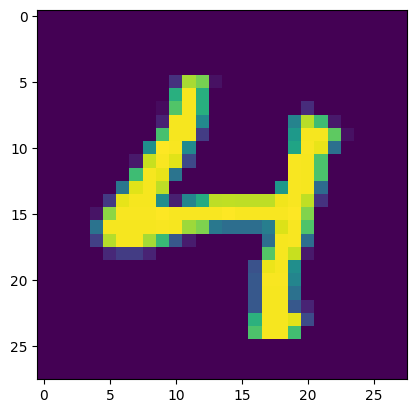

In [16]:
import matplotlib.pyplot as plt

plt.imshow(df.iloc[14258,1:].values.reshape(28,28))

In [40]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y ,test_size = 0.2, random_state = 43)

In [42]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [43]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [44]:
y_pred = knn.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9685714285714285

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [47]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [58]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 200)

In [59]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [60]:
X_train_trf.shape

(33600, 200)

In [61]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf, y_train)

KNeighborsClassifier()

In [62]:
y_pred = knn.predict(X_test_trf)

In [63]:
accuracy_score(y_test,y_pred)

0.9517857142857142

In [68]:
accuracy = 0
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)
    y_pred = knn.predict(X_test_trf)
    print(i,accuracy_score(y_test,y_pred))
   

1 0.25547619047619047
2 0.3320238095238095
3 0.5072619047619048
4 0.6614285714285715
5 0.7341666666666666
6 0.8280952380952381
7 0.8444047619047619
8 0.8723809523809524
9 0.8870238095238095
10 0.9058333333333334
11 0.9129761904761905
12 0.9153571428571429
13 0.9254761904761905
14 0.9325
15 0.9334523809523809
16 0.9353571428571429
17 0.9365476190476191
18 0.9380952380952381
19 0.9419047619047619
20 0.9436904761904762
21 0.945
22 0.9458333333333333
23 0.9467857142857142
24 0.9465476190476191
25 0.9472619047619047
26 0.9470238095238095
27 0.9492857142857143
28 0.9492857142857143
29 0.9507142857142857
30 0.9517857142857142
31 0.9530952380952381
32 0.9535714285714286
33 0.9511904761904761
34 0.9526190476190476
35 0.9548809523809524
36 0.9536904761904762
37 0.955952380952381
38 0.9542857142857143
39 0.9545238095238096
40 0.9539285714285715
41 0.9533333333333334
42 0.9552380952380952
43 0.9548809523809524
44 0.9544047619047619
45 0.9541666666666667
46 0.955
47 0.9554761904761905
48 0.95547619

KeyboardInterrupt: 

In [69]:
#transforming to a 2D coordinate system
pca = PCA(n_components =2)
X_train_trf= pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [73]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x= X_train_trf[:,0],
                y = X_train_trf[:,1],
                color = y_train_trf,
                color_discrete_sequence = px.colors.qualitative.G10)
fig.show()

In [74]:
#transforming to a 3D coordinate system
pca = PCA(n_components =3)
X_train_trf= pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [75]:
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x= X_train_trf[:,0],y= X_train_trf[:,1],z= X_train_trf[:,2],
                   color = y_train_trf)
fig.update_layout(
    margin = dict(l = 20, r = 20, b =20)
)
fig.show()

In [77]:
pca.explained_variance_
#eigen values

array([40.58305649, 29.18765693, 26.88929919])

In [79]:
pca.components_.shape
#Eigen vectors

(3, 784)

In [81]:
pca.explained_variance_ratio_*100

array([5.77266695, 4.15174797, 3.82482204])

In [82]:
#transforming to a 3D coordinate system
pca = PCA(n_components =None)
X_train_trf= pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [83]:
pca.explained_variance_.shape

(784,)

In [84]:
pca.explained_variance_ratio_*100

array([5.77266695e+00, 4.15174797e+00, 3.82482204e+00, 2.96553090e+00,
       2.57121506e+00, 2.25844181e+00, 1.96997383e+00, 1.78484920e+00,
       1.57560855e+00, 1.44114071e+00, 1.38142201e+00, 1.23024570e+00,
       1.14076273e+00, 1.12478915e+00, 1.05688711e+00, 1.01278458e+00,
       9.58347050e-01, 9.45686380e-01, 9.15366248e-01, 8.91462447e-01,
       8.45978634e-01, 8.16964134e-01, 7.80450220e-01, 7.55844453e-01,
       7.32988218e-01, 7.03993872e-01, 6.99468472e-01, 6.72420953e-01,
       6.37178998e-01, 6.26564033e-01, 6.15732591e-01, 6.03354910e-01,
       5.87885005e-01, 5.77687765e-01, 5.73363784e-01, 5.54627025e-01,
       5.43335255e-01, 5.33175304e-01, 5.15415149e-01, 4.92288004e-01,
       4.88512838e-01, 4.81855968e-01, 4.67610116e-01, 4.59482722e-01,
       4.57130950e-01, 4.49981596e-01, 4.45060793e-01, 4.43308454e-01,
       4.40180416e-01, 4.29254817e-01, 4.19699007e-01, 4.13931381e-01,
       4.07767573e-01, 4.01023021e-01, 3.97516912e-01, 3.91068904e-01,
      

In [86]:
np.cumsum(pca.explained_variance_ratio_*100)

array([  5.77266695,   9.92441492,  13.74923696,  16.71476786,
        19.28598293,  21.54442474,  23.51439857,  25.29924777,
        26.87485632,  28.31599703,  29.69741904,  30.92766474,
        32.06842747,  33.19321663,  34.25010373,  35.26288831,
        36.22123536,  37.16692174,  38.08228799,  38.97375044,
        39.81972907,  40.6366932 ,  41.41714342,  42.17298788,
        42.90597609,  43.60996997,  44.30943844,  44.98185939,
        45.61903839,  46.24560242,  46.86133501,  47.46468992,
        48.05257493,  48.63026269,  49.20362648,  49.7582535 ,
        50.30158876,  50.83476406,  51.35017921,  51.84246721,
        52.33098005,  52.81283602,  53.28044614,  53.73992886,
        54.19705981,  54.6470414 ,  55.0921022 ,  55.53541065,
        55.97559107,  56.40484588,  56.82454489,  57.23847627,
        57.64624385,  58.04726687,  58.44478378,  58.83585268,
        59.21414231,  59.58885647,  59.95793576,  60.32278872,
        60.68504789,  61.03804056,  61.38766815,  61.72

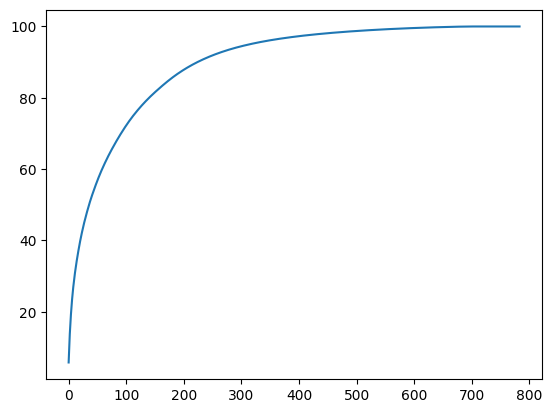

In [87]:
plt.plot(np.cumsum(pca.explained_variance_ratio_*100))